In [114]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np

# Análisis del flotador

## Extracción de datos en el dominio del tiempo

Los resultados se guardan en SeaFEM en ficheros .res, por lo que hay que adecuarlos al formato Pandas Dataframe.

In [2]:
path = rf'D:\arturo_sim\simulaciones\acoplado'
dataframes = {} #Almacen en formato diccionario para poder etiquetar los df de cada simulación con la regla establecida
mooring = {}

Sea --> oleaje de mayor (3) a menor(1) severidad, variando Hs y Tp

Direction --> Dirección oleaje. 0 = 0º / 1 = 120º / 2 = 240º

In [3]:
for direction in range(0,3):
    for sea in range(1,4):

        # Abrimos y extraemos la información del archivo .res
        res_path = os.path.join(path,f'oc4_{direction}_{sea}.gid',f'oc4_{direction}_{sea}.BodyKinematics.res')
        with open(res_path,'rb') as res:
            res_data = res.read().decode('utf-8', errors='ignore')

        # Escribimos la información del .res en un .txt
        txt_path = os.path.join(path,'txt',f'oc4_{direction}_{sea}.txt')
        with open(txt_path, 'w', encoding='utf-8') as txt_file:
            txt_file.write(res_data)

        # Almaceno los resultados del número de simulaciones empleado
        dataframes[f'df_{direction}_{sea}'] = pd.read_csv(txt_path, sep='\t', header=4).iloc[:,:7]


In [4]:
dataframes.keys()

dict_keys(['df_0_1', 'df_0_2', 'df_0_3', 'df_1_1', 'df_1_2', 'df_1_3', 'df_2_1', 'df_2_2', 'df_2_3'])

In [106]:
df = dataframes['df_1_2']

max_elev = df['Surge'].max()
max_time = df.loc[df['Surge']== max_elev,'time[s]'].values[0]

print(max_elev)
print(max_time)

1.4486360482168639
332.0


In [39]:
dataframes.keys()

dict_keys(['df_0_1', 'df_0_2', 'df_0_3', 'df_1_1', 'df_1_2', 'df_1_3', 'df_2_1', 'df_2_2', 'df_2_3'])

## Representaciones

Representación de los periodos con amplitudes más críticas

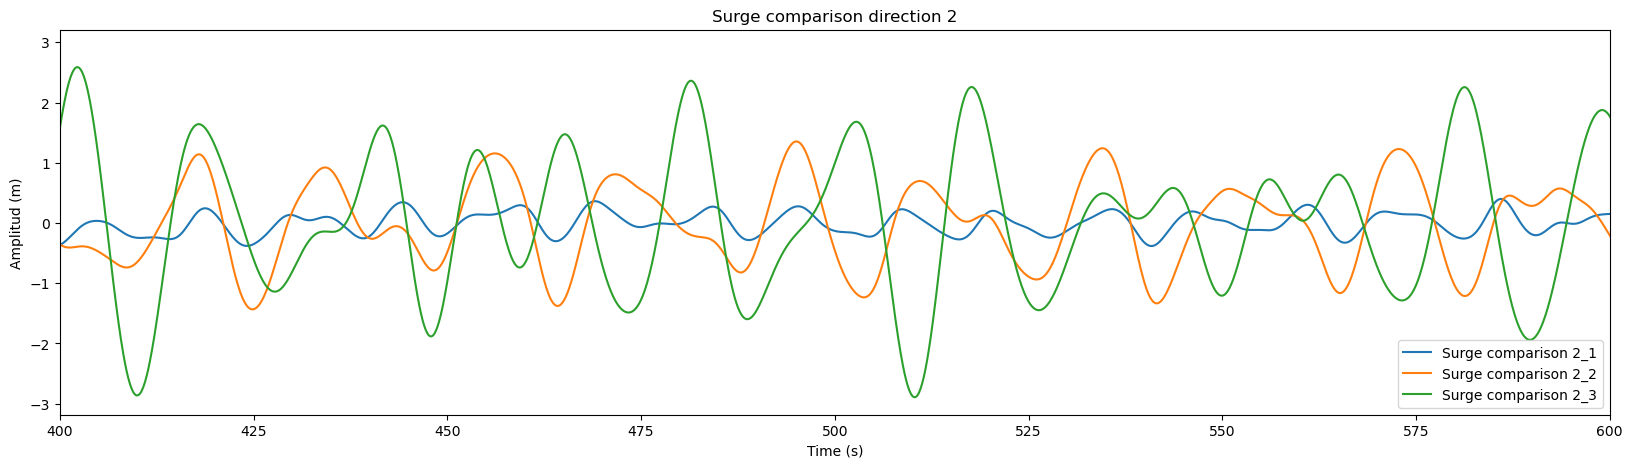

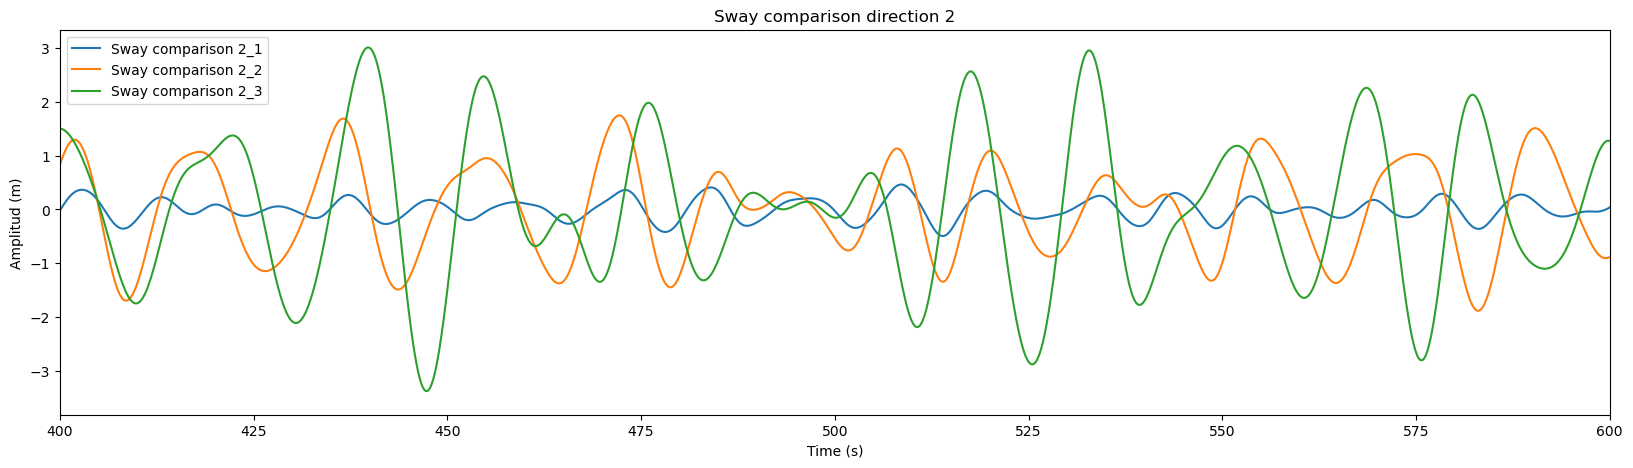

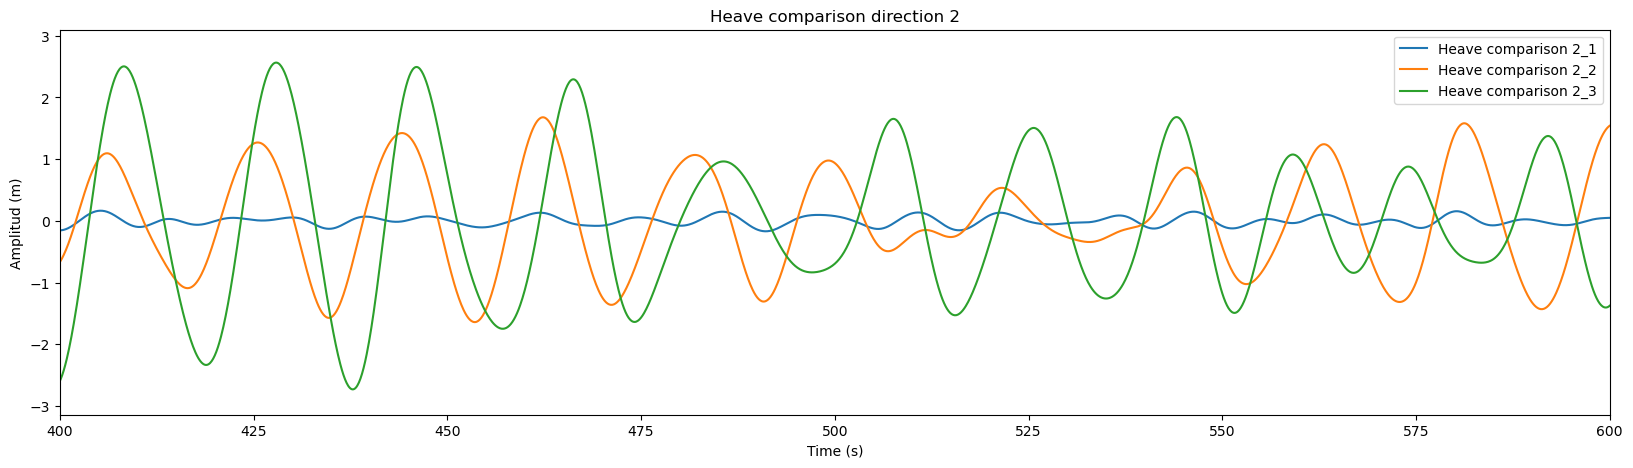

In [90]:
movements = ['Surge','Sway','Heave']
for mov in movements:
    plt.figure(figsize=(20, 5))

    for direction in range(2,3):
        for sea in range(1,4):
            df = dataframes[f'df_{direction}_{sea}']
            if mov in df.columns:
                df[mov] = df[mov]-df[mov].mean() # Ajuste para llevar información a la posición de equilibrio
                plt.plot(df['time[s]'],df[mov],label=f"{mov} comparison {direction}_{sea}")
            
    plt.xlabel('Time (s)')
    if mov in movements[0:3]:
        plt.ylabel('Amplitud (m)')
    else:
        plt.ylabel('grados (º)')
    plt.title(f"{mov} comparison direction {direction}")
    plt.legend()
    plt.xlim(400,600)
    plt.show()

In [ ]:
movements = ['Surge','Sway','Heave']
for mov in movements:
    plt.figure(figsize=(20, 5))

    for key, df in dataframes.items():
        if mov in df.columns:
            df[mov] = df[mov]-df[mov].mean() # Ajuste para llevar información a la posición de equilibrio
            plt.plot(df['time[s]'],df[mov],label=f"{mov} comparison {key}")
            
    plt.xlabel('Time (s)')
    if mov in movements[0:3]:
        plt.ylabel('Amplitud (m)')
    else:
        plt.ylabel('grados (º)')
    plt.title(f"{mov} comparison")
    plt.legend()
    plt.xlim(400,600)
    plt.show()

El registro máximo para cada dirección y oleaje

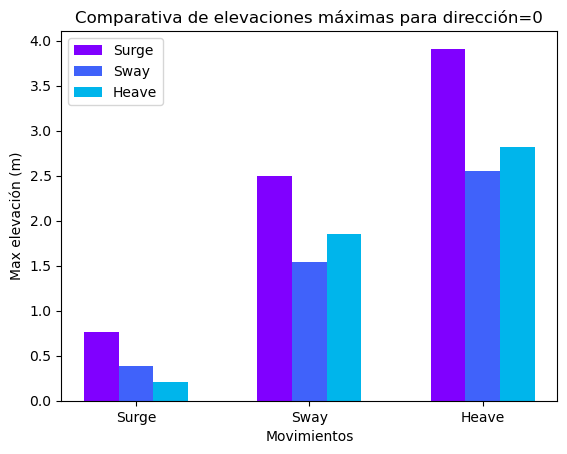

In [155]:
movements = ['Surge','Sway','Heave']

posiciones = np.arange(3)
colores = plt.cm.rainbow(np.linspace(0, 1, len(dataframes)))
for i, mov in enumerate(movements):
    df1 = dataframes['df_0_1'][[mov]].copy()
    df2 = dataframes['df_0_2'][[mov]].copy()
    df3 = dataframes['df_0_3'][[mov]].copy()

    df1[mov] = df1[mov] - df1[mov].mean()
    df2[mov] = df2[mov] - df2[mov].mean()
    df3[mov] = df3[mov] - df3[mov].mean()

    max_elev1 = df1[mov].max()
    max_elev2 = df2[mov].max()
    max_elev3 = df3[mov].max()

    alturas = [max_elev1, max_elev2, max_elev3]

    plt.bar(posiciones - 0.2+i*0.2, alturas, width=0.2,label=f"{mov}", color=colores[i])
    #plt.bar(posiciones, max_elev2, width=0.2,label=f"{mov} df_0_2", color='blue')
    #plt.bar(posiciones + 0.2, max_elev3, width=0.2,label=f"{mov} df_0_3", color='red')

plt.xlabel('Movimientos')
plt.ylabel('Max elevación (m)')
plt.title("Comparativa de elevaciones máximas para dirección=0")
plt.xticks(posiciones, movements)
plt.legend()
plt.show()

## Analisis espectral